### Logreg on PERCH embeddings of tropical alarm calls for specific labelled calls (B vs C ...)

In [1]:
%pip install git+https://github.com/kitzeslab/bioacoustics-model-zoo
%pip install tensorflow tensorflow-hub
%pip install iterative-stratification
%pip install umap-learn seaborn

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/kitzeslab/bioacoustics-model-zoo to /private/var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/pip-req-build-4g846qhq
  Running command git clone -q https://github.com/kitzeslab/bioacoustics-model-zoo /private/var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/pip-req-build-4g846qhq
  Resolved https://github.com/kitzeslab/bioacoustics-model-zoo to commit b3f2761f33116b70df353384d286a06b2a21fe70
  distutils: /private/var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/pip-build-env-fqwwsqhn/normal/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/site-packages
  distutils: /private/var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/pip-build-env-fqwwsqhn/normal/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/site-packages
  user = False
  home = None
  root = None
  prefix = '/private/var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/pip-build-env-fqwwsqhn/normal'
  distu

In [2]:
import torch
import random
import numpy as np
torch.manual_seed(0)
random.seed(0)
np.random.seed(0)

In [3]:
import pandas as pd
from pathlib import Path
from glob import glob

# Set path to FFL-Annotations
dataset_path = Path("./FFL-Annotations/")
annotation_files = sorted(glob(f"{dataset_path}/Data/*.txt"))

print("Checking counts with deduplication enabled:")
raw_counts = {}

for ann_file in annotation_files:
    # Use usecols to ensure drop_duplicates compares the right data
    # and to save memory, similar to Snippet 1
    try:
        # We read the file to check headers first
        header = pd.read_csv(ann_file, sep='\t', nrows=0).columns
        call_col = 'TYPE' if 'TYPE' in header else 'CALL'
        
        # Now read only the relevant columns
        cols_to_load = ['SPP', call_col, 'Begin Time (s)', 'End Time (s)', 'Low Freq (Hz)', 'High Freq (Hz)']
        df = pd.read_csv(ann_file, sep='\t', usecols=cols_to_load)
        
        # removes identical rows in the same file (spectrogram 1 vs spectrogram 2)
        rows_before = len(df)
        df = df.drop_duplicates()
        rows_after = len(df)
        
        if rows_before > rows_after:
            print(f"  Removed {rows_before - rows_after} duplicates from {Path(ann_file).name}")


        df['SPECIES_CALL'] = df['SPP'] + '_' + df[call_col]
        
        for label, count in df['SPECIES_CALL'].value_counts().items():
            if label not in raw_counts:
                raw_counts[label] = 0
            raw_counts[label] += count
            
    except Exception as e:
        print(f"Error processing {ann_file}: {e}")

# Show results
sorted_counts = sorted(raw_counts.items(), key=lambda x: x[1], reverse=True)
# print("\nTop 10 counts across all files (Deduplicated):")
# for label, count in sorted_counts[:10]:
#     print(f"  {label}: {count}")
print("\nTop counts across all files:")
for label, count in sorted_counts:
    print(f"  {label}: {count}")


Checking counts with deduplication enabled:
  Removed 33 duplicates from TRIAL4_HAWK_14JUN2024.txt
  Removed 71 duplicates from TRIAL5_HAWK_14JUN2024.txt
  Removed 81 duplicates from TRIAL7_HAWK_15JUN2024.txt

Top counts across all files:
  HARU_C1: 479
  THAR_B2: 197
  THAR_B1: 188
  THAR_P1: 56
  MYME_C1: 55
  MYSP_C1: 51
  THAR_P2: 49
  MYLO_C2: 48
  MYLO_C4: 43
  HARU_C2: 36
  MYAX_C3: 34
  MYMY_C1: 31
  MYAX_C2: 28
  MYAX_C1: 22
  MYLO_C3: 20
  MYLO_C1: 19
  THAR_P3: 16
  MYLO_C6: 14
  MYLO_C5: 12
  MYME_C2: 11
  MYAX_S1: 8
  TOAS_S1: 8
  MYAX_C4: 7
  MYAX_C5: 6
  HARU_S1: 5
  HARU_C4: 4
  HARU_C3: 4
  MYSP_C3: 3
  THAR_B3: 3
  UNK_C1: 2
  THAR_S1: 1
  HARU_B2: 1
  MYLO_S1: 1
  EPHA_S1: 1
  MYSP_C2: 1
  CR_C1: 1
  MYME|C1_C5: 1
  MYSP`_C1: 1


In [4]:
from opensoundscape.annotations import BoxedAnnotations
from pathlib import Path
from glob import glob
import pandas as pd

# Set paths
dataset_path = Path("./FFL-Annotations/")
annotation_files = sorted(glob(f"{dataset_path}/Data/*.txt"))

# Build corresponding audio file paths
audio_files = []
valid_raven_files = []

for raven_path_str in annotation_files:
    raven_path = Path(raven_path_str)
    audio_filename = f"{raven_path.stem}_VILLAANA_MADREDEDIOS.wav"
    audio_path = dataset_path / "Audio" / audio_filename
    
    if audio_path.exists():
        valid_raven_files.append(raven_path)
        audio_files.append(audio_path)
    else:
        print(f"WARNING: Audio file {audio_path} not found, skipping {raven_path.name}")

print(f"Found {len(valid_raven_files)} Raven files with matching audio")

# Load annotations using from_raven_files
boxed_annotations = BoxedAnnotations.from_raven_files(
    raven_files=valid_raven_files,
    audio_files=audio_files,
    annotation_column=None,
    keep_extra_columns=True,
    warn_no_annotations=False
)

print(f"Loaded {len(boxed_annotations.df)} annotations")
# print(boxed_annotations.df[['CALL','TYPE']])
# Combine TYPE and CALL columns (both could exist, use whichever has the value)
if 'TYPE' in boxed_annotations.df.columns and 'CALL' in boxed_annotations.df.columns:
    boxed_annotations.df['call_type'] = boxed_annotations.df['TYPE'].fillna(boxed_annotations.df['CALL'])
elif 'TYPE' in boxed_annotations.df.columns:
    boxed_annotations.df['call_type'] = boxed_annotations.df['TYPE']
else:
    boxed_annotations.df['call_type'] = boxed_annotations.df['CALL']



# Drop rows with missing data

missing_data_rows = boxed_annotations.df[boxed_annotations.df[['SPP', 'call_type']].isna().any(axis=1)]
print("Missing data rows: ")
display(missing_data_rows[['audio_file', 'start_time', 'end_time', 'SPP', 'call_type']])

boxed_annotations.df = boxed_annotations.df.dropna(subset=['SPP', 'call_type'])
print(len(boxed_annotations.df))
# Create annotation
boxed_annotations.df['annotation'] = boxed_annotations.df['SPP'] + '_' + boxed_annotations.df['call_type']
# annotations for more generalized call types
boxed_annotations.df['annotation'] = boxed_annotations.df['SPP'] + '_' + boxed_annotations.df['call_type'].astype(str).str[0]

# Remove duplicates
boxed_annotations.df = boxed_annotations.df.drop_duplicates(
    subset=['audio_file', 'start_time', 'end_time', 'annotation']
).reset_index(drop=True)

print(f"\nFinal: {len(boxed_annotations.df)} unique annotations")
print(f"\nFirst few rows:")
print(boxed_annotations.df[['audio_file', 'start_time', 'end_time', 'SPP', 'call_type', 'annotation']].head())
print(f"\nLabel distribution:")
print(boxed_annotations.df['annotation'].value_counts().head(10))


/Users/ariel/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 44 Raven files with matching audio
Loaded 1653 annotations
Missing data rows: 


,audio_file,start_time,end_time,SPP,call_type
927,FFL-Annotations/Audio/TRIAL3_HAWK_13JUN2024_VI...,0.069488,0.483637,MYAX?,NaN


1652

Final: 1467 unique annotations

First few rows:
                                          audio_file  start_time  end_time  \
0  FFL-Annotations/Audio/TRIAL10_HAWK_17JUN2024_V...    0.281217  0.336000   
1  FFL-Annotations/Audio/TRIAL10_HAWK_17JUN2024_V...    0.440695  0.496695   
2  FFL-Annotations/Audio/TRIAL10_HAWK_17JUN2024_V...    0.646434  0.779130   
3  FFL-Annotations/Audio/TRIAL10_HAWK_17JUN2024_V...    0.989739  1.095652   
4  FFL-Annotations/Audio/TRIAL10_HAWK_17JUN2024_V...    1.333043  1.434086   

    SPP call_type annotation  
0  THAR        P1     THAR_P  
1  THAR        P1     THAR_P  
2  THAR        P1     THAR_P  
3  THAR        P1     THAR_P  
4  THAR        P1     THAR_P  

Label distribution:
annotation
HARU_C    523
THAR_B    388
MYLO_C    156
THAR_P    121
MYAX_C     97
MYME_C     66
MYSP_C     55
MYMY_C     31
TOAS_S      8
MYAX_S      8
Name: count, dtype: int64


In [5]:
labels = boxed_annotations.clip_labels(clip_duration=2, min_label_overlap=0.05) #0.05 best
labels.sum().sort_values(ascending=False)

THAR_B       318
HARU_C       209
MYLO_C       167
MYME_C        79
MYAX_C        79
THAR_P        63
MYSP_C        40
MYAX_S        17
MYMY_C        17
HARU_S         7
TOAS_S         6
MYLO_S         3
THAR_S         3
EPHA_S         2
HARU_B         1
UNK_C          1
CR_C           1
MYME|C1_C      1
MYSP`_C        1
dtype: int64

In [6]:
# include MYAX calls 
# MYMY ignore, could be confused with THAR_B2

In [7]:
# top_labels = ["HARU_C1","THAR_B2","THAR_B1","THAR_P1","MYME_C1","MYSP_C1","THAR_P2","MYLO_C2","MYLO_C4","HARU_C2"]
top_labels = ["THAR_B", "HARU_C", "MYLO_C", "MYME_C", "MYAX_C", "THAR_P"]

In [8]:
labels_multi = labels[top_labels].copy()
# if every label in the column is 0 mark it as NOISE
# labels_multi["NOISE"] = (labels_multi.sum(axis=1) == 0).astype(int)
# top_labels.append("NOISE")
print(labels_multi.sum())

THAR_B    318
HARU_C    209
MYLO_C    167
MYME_C     79
MYAX_C     79
THAR_P     63
dtype: int64


In [9]:
import bioacoustics_model_zoo as bmz
import shutil
from pathlib import Path

tfhub_cache = Path("/var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/tfhub_modules")
if tfhub_cache.exists():
    print(f"Clearing TensorFlow Hub cache at {tfhub_cache}")
    shutil.rmtree(tfhub_cache)
    print("Cache cleared. Model will re-download.")
    
perch = bmz.Perch()

print(f"PERCH model loaded: {type(perch)}")
# Embed all clips with PERCH (same approach as the single-label section)
embeddings_multi = perch.embed(
    labels_multi,
    return_dfs=False,  # Returns numpy array instead of DataFrame
    batch_size=128,     # Adjust based on your RAM
    num_workers=0       # Use 0 on Mac to avoid multiprocessing issues
)

print(f"Embeddings shape: {embeddings_multi.shape}")
print(f"Expected: ({len(labels_multi)}, embedding_dimension)")

Clearing TensorFlow Hub cache at /var/folders/kb/88tc0y855kl0ynfnf_vk274c0000gn/T/tfhub_modules
Cache cleared. Model will re-download.
PERCH model loaded: <class 'bioacoustics_model_zoo.perch.Perch'>


/Users/ariel/Library/Python/3.9/lib/python/site-packages/opensoundscape/ml/cnn.py:599: UserWarning: 
                    This architecture is not listed in opensoundscape.ml.cnn_architectures.ARCH_DICT.
                    It will not be available for loading after saving the model with .save() (unless using pickle=True). 
                    To make it re-loadable, define a function that generates the architecture from arguments: (n_classes, n_channels) 
                    then use opensoundscape.ml.cnn_architectures.register_architecture() to register the generating function.

                    The function can also set the returned object's .constructor_name to the registered string key in ARCH_DICT
                    to avoid this warning and ensure it is reloaded correctly by opensoundscape.ml.load_model().

                    See opensoundscape.ml.cnn_architectures module for examples of constructor functions
                    
  warnings.warn(
/Users/ariel/Library/Python/

  0%|          | 0/11 [00:00<?, ?it/s]

/Users/ariel/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
2026-04-14 14:26:46.845431: I external/local_xla/xla/service/service.cc:163] XLA service 0x396eb0820 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-04-14 14:26:46.845582: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2026-04-14 14:26:47.011912: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-14 14:26:47.057358: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator jax2tf_infer_fn_/assert_equal_1/Assert/AssertGuard/Assert
I0000 00:00:1776202007.763681  674576 device_compiler.h:196] Compiled cluster using XLA!  Thi

Embeddings shape: (1307, 1280)
Expected: (1307, embedding_dimension)


In [10]:
import pandas as pd
import numpy as np

# Convert embeddings to DataFrame and align with labels (same as single-label section)
embeddings_multi_df = pd.DataFrame(
    embeddings_multi,
    index=labels_multi.index
)

# Multi-label target matrix: shape (n_clips, n_labels)
Y = labels_multi[top_labels].astype(int).values

print(f"Features (X): {embeddings_multi_df.shape}")
print(f"Labels (Y): {Y.shape}")
print(f"\nSamples positive per label:")
for i, label in enumerate(top_labels):
    print(f"  {label}: {Y[:, i].sum()}")



# # Convert embeddings to DataFrame and align with labels
# import pandas as pd
# import numpy as np

# # embeddings_df is a numpy array, convert to DataFrame with same index as labels
# embeddings_df = pd.DataFrame(
#     embeddings_df,
#     index=labels_haru.index
# )

# # Get the target labels (HARU_C1 presence/absence)
# y = labels_haru['THAR_B1'].astype(int).values  # Convert boolean to 0/1

# print(f"Features (X): {embeddings_df.shape}")
# print(f"Labels (y): {y.shape}")
# print(f"Positive samples (HARU_C1 present): {y.sum()}")
# print(f"Negative samples (HARU_C1 absent): {(y == 0).sum()}")
# print(f"Class imbalance ratio: {(y == 0).sum() / y.sum():.1f}:1")

Features (X): (1307, 1280)
Labels (Y): (1307, 6)

Samples positive per label:
  THAR_B: 318
  HARU_C: 209
  MYLO_C: 167
  MYME_C: 79
  MYAX_C: 79
  THAR_P: 63


In [11]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# trying to do custom stratification
labels_per_file = labels_multi.groupby(level=0).max()

#filepaths
files_X = labels_per_file.index.values
#binary matrix per filepath
files_Y = labels_per_file.values

#stratify the files, not the labels, using with multilabel stratified kfold
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=0)


custom_folds = []

for train_file_idx, test_file_idx in mskf.split(files_X, files_Y):
    train_files = files_X[train_file_idx]
    test_files = files_X[test_file_idx]

    #map files back to df
    original_file_idx = labels_multi.index.get_level_values(0)

    train_clip_idx = np.where(original_file_idx.isin(train_files))[0]
    test_clip_idx = np.where(original_file_idx.isin(test_files))[0]
    
    custom_folds.append((train_clip_idx, test_clip_idx))


# test the distributions to see if they are balanced
for fold_idx, (train_idx, test_idx) in enumerate(custom_folds):
    print(f"\n{'='*50}")
    print(f"Fold {fold_idx + 1}")
    print(f"  Train clips: {len(train_idx)}, Test clips: {len(test_idx)}")
    
    train_labels = labels_multi.iloc[train_idx]
    test_labels = labels_multi.iloc[test_idx]

    print(f"  {'Label':<30} {'Train':>10} {'Test':>10}")
    print(f"  {'-'*52}")
    for col in labels_multi.columns:
        train_pct = train_labels[col].mean() * 100
        test_pct = test_labels[col].mean() * 100
        print(f"  {col:<30} {train_pct:>9.1f}% {test_pct:>9.1f}%")


Fold 1
  Train clips: 1007, Test clips: 300
  Label                               Train       Test
  ----------------------------------------------------
  THAR_B                              25.1%      21.7%
  HARU_C                              18.5%       7.7%
  MYLO_C                               9.2%      24.7%
  MYME_C                               5.6%       7.7%
  MYAX_C                               5.7%       7.3%
  THAR_P                               5.4%       3.0%

Fold 2
  Train clips: 1071, Test clips: 236
  Label                               Train       Test
  ----------------------------------------------------
  THAR_B                              24.0%      25.8%
  HARU_C                              15.0%      20.3%
  MYLO_C                              14.5%       5.1%
  MYME_C                               5.7%       7.6%
  MYAX_C                               6.9%       2.1%
  THAR_P                               4.9%       4.7%

Fold 3
  Train clips: 1071, T

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neural_network import MLPClassifier  
from sklearn.ensemble import RandomForestClassifier
  

# One logistic regression per label, with class-weight balancing (same settings as single-label)
base_logreg = LogisticRegression(
    class_weight='balanced',  # handles class imbalance per label
    C=0.1, # regularization
    max_iter=1000,
    random_state=43
)
multi_logreg = MultiOutputClassifier(base_logreg)

base_mlp = MLPClassifier(
    hidden_layer_sizes=(1000,),
    max_iter=1000,
    random_state=42
)

base_randforest = RandomForestClassifier(
    class_weight='balanced'
)
# multi_mlp = MultiOutputClassifier(base_mlp)

THRESHOLD CALIBRATION


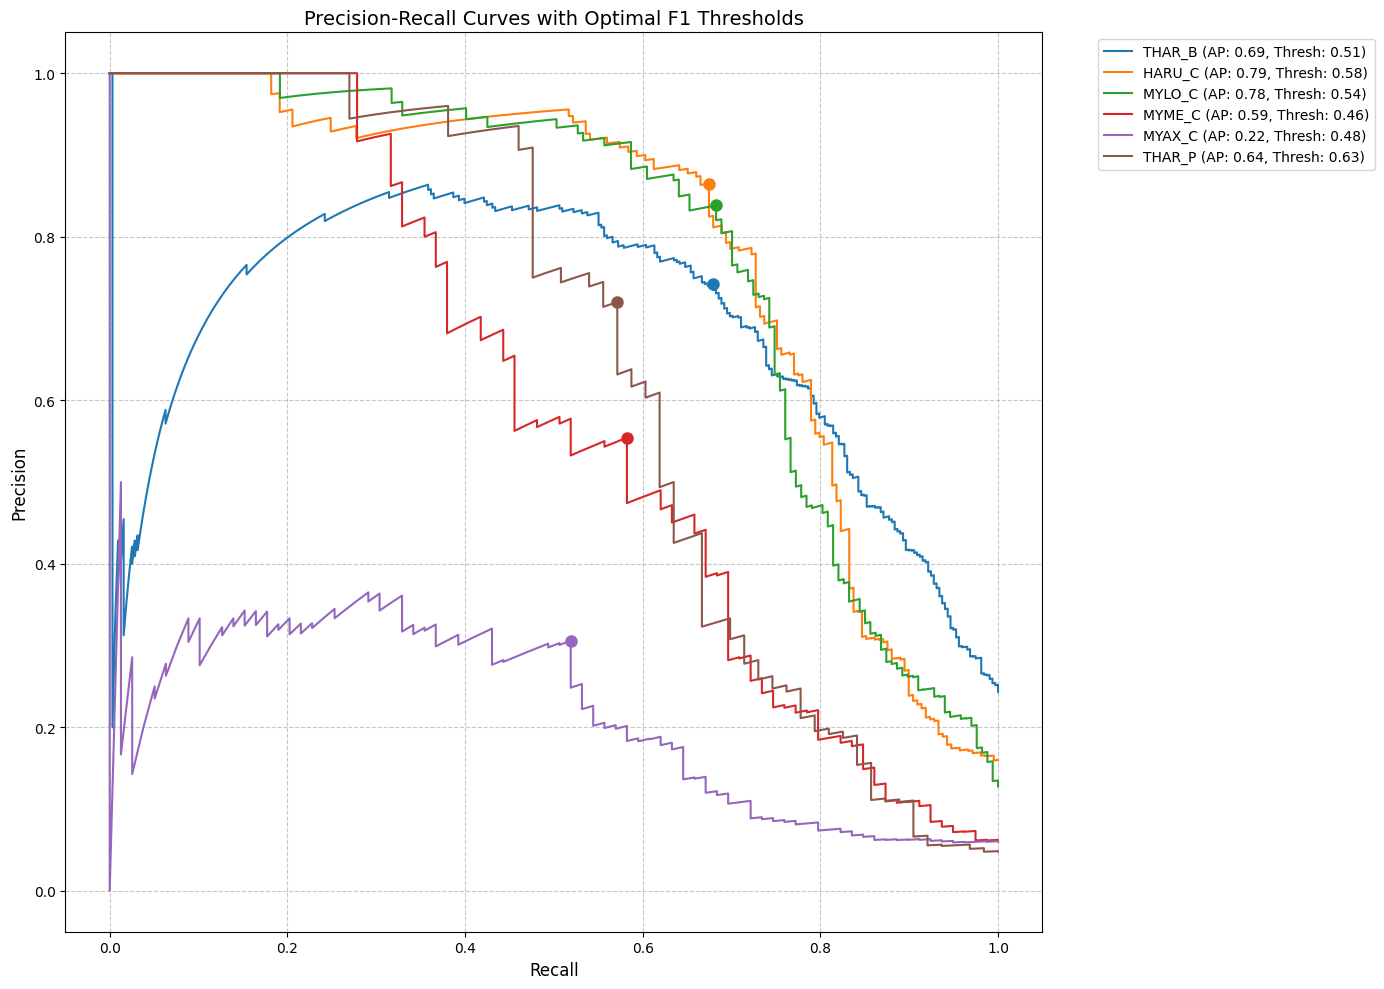


Optimal Thresholds (Maximized for F1):
  THAR_B      : 0.508
  HARU_C      : 0.581
  MYLO_C      : 0.538
  MYME_C      : 0.463
  MYAX_C      : 0.475
  THAR_P      : 0.632


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

print("="*50)
print("THRESHOLD CALIBRATION")
print("="*50)

# initialize arrays to hold out of fold predictions and true labels
oof_Y_true = np.zeros_like(Y, dtype=float)
oof_Y_proba = np.zeros_like(Y, dtype=float)

# get predictions from folds
for train_emb, test_emb in custom_folds:
    # Split features and targets
    X_train, X_test = embeddings_multi_df.iloc[train_emb], embeddings_multi_df.iloc[test_emb]
    Y_train, Y_test = Y[train_emb], Y[test_emb]

    # Train
    multi_logreg.fit(X_train, Y_train)

    # Predict probabilities
    y_pred_proba_raw = multi_logreg.predict_proba(X_test)
    Y_pred_proba_positive = np.array([label_probs[:, 1] for label_probs in y_pred_proba_raw]).T

    # Store true labels and predicted probabilities for the test fold
    oof_Y_true[test_emb] = Y_test
    oof_Y_proba[test_emb] = Y_pred_proba_positive

# calculate PR Curves and find the optimal threshold for each class
best_thresholds = {}

plt.figure(figsize=(14, 10))

for i, label in enumerate(top_labels):
    y_true_class = oof_Y_true[:, i]
    y_proba_class = oof_Y_proba[:, i]

    # generate precision, recall, and threshold arrays
    precision, recall, thresholds = precision_recall_curve(y_true_class, y_proba_class)
    
    # get f1 scores
    f1_scores = np.divide(
        2 * precision * recall, 
        precision + recall, 
        out=np.zeros_like(precision), 
        where=(precision + recall) != 0
    )

    # find highest f1 score
    best_idx = np.argmax(f1_scores)
    best_f1 = f1_scores[best_idx]
    
    # thresholds array has length len(precision) - 1, so we handle the last index safely
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 1.0
    best_thresholds[label] = best_thresh

    # Plot the PR curve for this label
    ap_score = average_precision_score(y_true_class, y_proba_class)
    line, = plt.plot(recall, precision, label=f'{label} (AP: {ap_score:.2f}, Thresh: {best_thresh:.2f})')
    
    # Mark the optimal F1 threshold point on the curve
    plt.plot(recall[best_idx], precision[best_idx], marker='o', markersize=8, color=line.get_color())

    # for t, p, r in zip(thresholds, precision, recall):
    # # Only label every 100th threshold (or specific intervals) to avoid clutter
    #     if np.isclose(t, [0.2, 0.4, 0.6, 0.8], atol=0.01).any():
    #         plt.annotate(f'Th:{t:.2f}', (r, p), textcoords="offset points", 
    #                     xytext=(0,10), ha='center', fontsize=8, alpha=0.7)

# Formatting the plot
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves with Optimal F1 Thresholds', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print out the dictionary of thresholds to use for future predictions
print("\nOptimal Thresholds (Maximized for F1):")
for label, thresh in best_thresholds.items():
    print(f"  {label:<12}: {thresh:.3f}")

In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings("ignore")

print("="*50)
print("MULTICLASS LOGISTIC REGRESSION")
print("="*50)

label_names = labels_multi.columns
logreg_results = {label: {'f1': []} for label in label_names}
detailed_analysis = []

# for fold, (train_emb, test_emb) in enumerate(gkf_multi.split(embeddings_multi_df, labels_multi, groups=audio_files_multi)):
for fold, (train_emb, test_emb) in enumerate(custom_folds):
    
    #Split features
    X_train, X_test = embeddings_multi_df.iloc[train_emb], embeddings_multi_df.iloc[test_emb]
    
    # get targets
    Y_train = labels_multi.iloc[train_emb].astype(int).values
    Y_test = labels_multi.iloc[test_emb].astype(int).values

    # Train
    multi_logreg.fit(X_train, Y_train)

    #Predict
    y_pred_proba_raw = multi_logreg.predict_proba(X_test)

    Y_pred_proba_positive = np.array([label_probs[:, 1] for label_probs in y_pred_proba_raw]).T

    # default 0.5 threshold
    # Y_pred = (Y_pred_proba_positive >= 0.5).astype(int) # custom threshold, tune per-class later?
    
    # custom threshold numbers from the precision recall curve from previous cell
    threshold_array = np.array([best_thresholds[label] for label in top_labels])
    Y_pred = (Y_pred_proba_positive >= threshold_array).astype(int)

    # # Metrics
    # fold_f1 = f1_score(y_test_labels, y_pred, average='macro', zero_division=0)
    # logreg_results['f1'].append(fold_f1)

    # Process metadata for CSV
    test_indexes = embeddings_multi_df.iloc[test_emb].index
    
    for i, label in enumerate(label_names):
        y_t = Y_test[:, i]
        y_p = Y_pred[:, i]
        
        # Calculate F1 for this specific bird in this fold
        fold_f1 = f1_score(y_t, y_p, zero_division=0)
        logreg_results[label]['f1'].append(fold_f1)
        
        for idx in range(len(y_t)):
            actual = y_t[idx]
            pred = y_p[idx]
            
            category = None
            if actual == 1 and pred == 1:
                category = 'true_positive'
            elif actual == 0 and pred == 1:
                category = 'false_positive'
            elif actual == 1 and pred == 0:
                category = 'false_negative'

            if category is not None:
                
                detailed_analysis.append({
                    'fold': fold + 1,
                    'audio_file': test_indexes[idx][0],
                    'begin_time': test_indexes[idx][1],
                    'end_time': test_indexes[idx][1] + 2, 
                    'label': label,
                    'probability': Y_pred_proba_positive[idx, i],
                    'error_type': category
                })

    print(f"Fold {fold + 1} completed.")

# Summary Stats
print("\nAverage F1 per label across folds:")
for label in label_names:
    mean_f1 = np.mean(logreg_results[label]['f1'])
    std_f1 = np.std(logreg_results[label]['f1'])
    print(f"  {label:<15}: F1 = {mean_f1:.3f} ± {std_f1:.3f}")

# Final CSV Output
errors_df = pd.DataFrame(detailed_analysis)
csv_filename = 'model_errors_detailed_multilabel.csv'
errors_df.to_csv(csv_filename, index=False)
print(f"\nReport saved: {len(errors_df)} individual label mismatches found ({csv_filename}).")

MULTICLASS LOGISTIC REGRESSION
Fold 1 completed.
Fold 2 completed.
Fold 3 completed.
Fold 4 completed.
Fold 5 completed.

Average F1 per label across folds:
  THAR_B         : F1 = 0.721 ± 0.099
  HARU_C         : F1 = 0.694 ± 0.182
  MYLO_C         : F1 = 0.672 ± 0.172
  MYME_C         : F1 = 0.577 ± 0.152
  MYAX_C         : F1 = 0.384 ± 0.032
  THAR_P         : F1 = 0.632 ± 0.051

Report saved: 1178 individual label mismatches found (model_errors_detailed_multilabel.csv).


# ignore MYSP

In [ ]:
# import pandas as pd
# from pathlib import Path

# TARGET_LABEL = "THAR_P"  # change to look at other calls
# INPUT_CSV = "model_errors_detailed_multilabel.csv"
# OUTPUT_DIR = Path(f"raven_analysis_{TARGET_LABEL}")

# OUTPUT_DIR.mkdir(exist_ok=True)

# print(f"Loading {INPUT_CSV}...")
# df = pd.read_csv(INPUT_CSV)

# # filter for bird
# target_df = df[df['label'] == TARGET_LABEL].copy()

# if len(target_df) == 0:
#     print(f"No logged classifications found for {TARGET_LABEL}.")
# else:
#     print(f"Found {len(target_df)} total logged classifications for {TARGET_LABEL}.")
    
#     print(target_df['error_type'].value_counts())
#     print("-" * 50)

#     # Group by audio file to create one Raven file per audio clip
#     files_created = 0
#     for audio_file, group in target_df.groupby('audio_file'):
        
#         # initialize raven formatted df
#         raven_df = pd.DataFrame()

#         # Standard Raven required columns
#         raven_df['Selection'] = range(1, len(group) + 1)
#         raven_df['View'] = 'Spectrogram 1'
#         raven_df['Channel'] = 1
#         raven_df['Begin Time (s)'] = group['begin_time'].values
#         raven_df['End Time (s)'] = group['end_time'].values
#         raven_df['Low Freq (Hz)'] = 0      # Adjust if you want a specific box height
#         raven_df['High Freq (Hz)'] = 22050 # Adjust if you want a specific box height
        
#         # Custom metadata columns
#         raven_df['Predicted Label'] = TARGET_LABEL
#         raven_df['Classification Type'] = group['error_type'].values
#         raven_df['Model Probability'] = group['probability'].values.round(4)
#         raven_df['Fold'] = group['fold'].values

#         # Format the output filename based on the audio file name
#         # E.g., FFL-Annotations/Audio/TRIAL1_...wav -> MYSP_C1_TRIAL1_...txt
#         audio_stem = Path(audio_file).stem
#         output_filename = f"{TARGET_LABEL}_analysis_{audio_stem}.txt"
#         output_filepath = OUTPUT_DIR / output_filename
        
#         # Save as a tab-separated text file
#         raven_df.to_csv(output_filepath, sep='\t', index=False)
#         files_created += 1

#     print(f"\nSuccess! Created {files_created} Raven selection tables in the '{OUTPUT_DIR.name}' folder.")